In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs import FITSFixedWarning
warnings.filterwarnings('ignore', category=FITSFixedWarning)

In [2]:
#!ls -ltr *.fits

In [3]:
# Open FITS file
with fits.open('/home/davas/Documents/cnn_astro/observational_images/gass_314_-28_1774393621.fits.gz') as hdul:
    
    # File structure
    #hdul.info()
    
    # Access header
    hdr = hdul[0].header
    
    # Access data
    data = hdul[0].data

# Access header
#print(hdr['OBJECT'])

# Check data
print(type(data), data.shape)
print(len(data))

<class 'numpy.ndarray'> (1201, 125, 125)
1201


In [4]:
#print(hdr)
print(len(data)//5, len(data)//5 + 1, 2*len(data)//5, 4*len(data)//5, 5*len(data)//5)

240 241 480 960 1201


In [5]:
# Integrate frequency axis
data_2d = np.sum(data, axis = 0)

# Velocity Channels
data_ch1 = np.sum(data[0:len(data)//5], axis =0)

data_ch2 = np.sum(data[len(data)//5 + 1:2*len(data)//5], axis =0)

data_ch3 = np.sum(data[2*len(data)//5 + 1:3*len(data)//5], axis =0)

data_ch4 = np.sum(data[3*len(data)//5 + 1:4*len(data)//5], axis =0)

data_ch5 = np.sum(data[4*len(data)//5 + 1:5*len(data)//5], axis =0)

# Check projected data
print(data_ch3.shape)

(125, 125)


In [6]:
# for i in range(len(data)):

#     plt.figure(figsize = (6,5))
#     plt.pcolor(data[i,:,:])
#     plt.show()

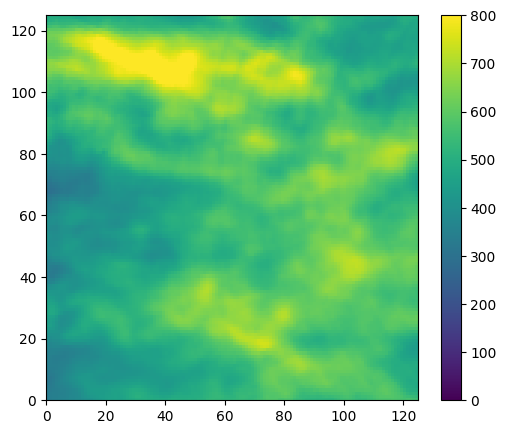

In [7]:
plt.figure(figsize = (6,5))

z = plt.pcolor(data_2d, vmin = 0, vmax = 800)

plt.colorbar(z)

plt.show()

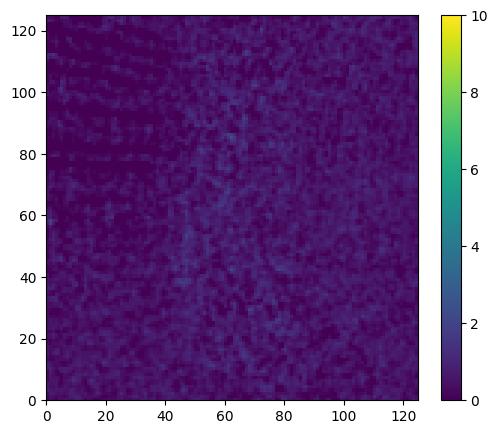

In [8]:
plt.figure(figsize = (6,5))

z = plt.pcolor(data_ch1, vmin = 0, vmax = 10)

plt.colorbar(z)

plt.show()

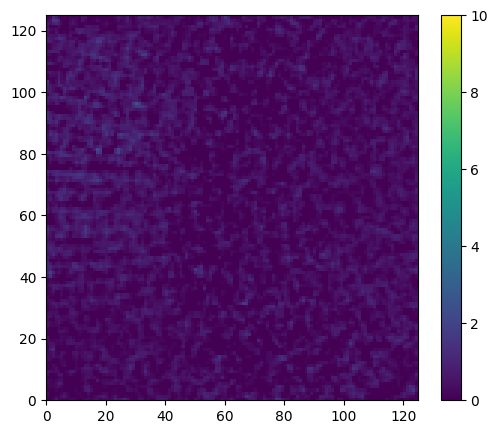

In [9]:
plt.figure(figsize = (6,5))

z = plt.pcolor(data_ch2, vmin = 0, vmax = 10)

plt.colorbar(z)

plt.show()

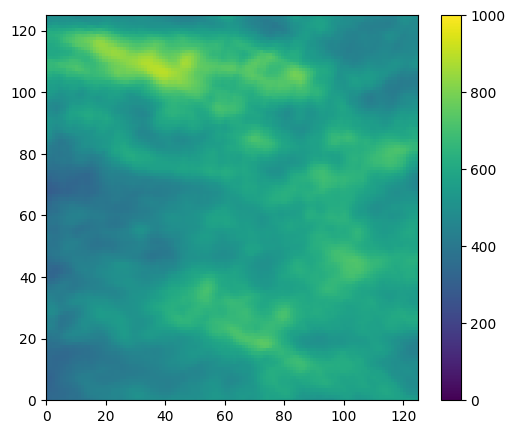

In [10]:
plt.figure(figsize = (6,5))

z = plt.pcolor(data_ch3, vmin = 0, vmax = 1000)

plt.colorbar(z)

plt.show()

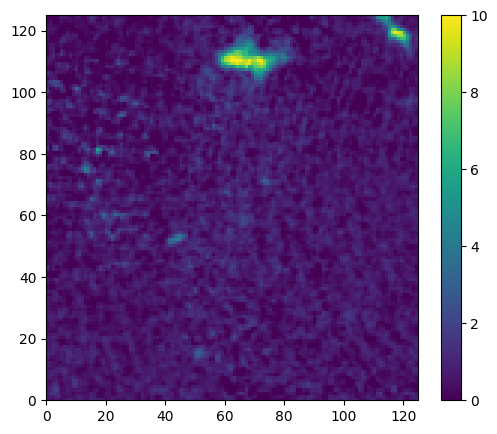

In [11]:
plt.figure(figsize = (6,5))

z = plt.pcolor(data_ch4, vmin = 0, vmax = 10)

plt.colorbar(z)

plt.show()

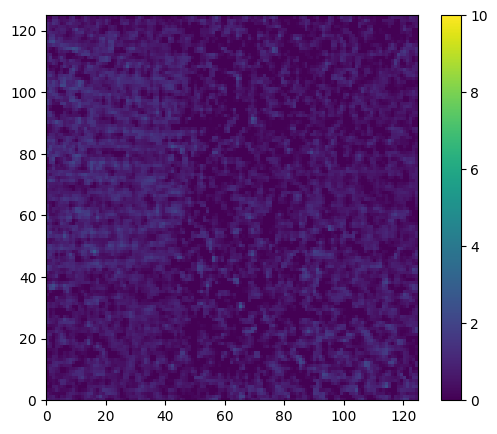

In [12]:
plt.figure(figsize = (6,5))

z = plt.pcolor(data_ch5, vmin = 0, vmax = 10)

plt.colorbar(z)

plt.show()

In [13]:
# Read header coordinates
#w = WCS(hdr)

# Print summary of the coordinate system
#print(w)

# Manually fix the problematic unit string
hdr['CUNIT3'] = 'm/s'

# Now it should initialize without the InvalidTransformError
w = WCS(hdr)

#print(w)

/home/davas/.uve/py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/davas/.uve/py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/davas/.uve/py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


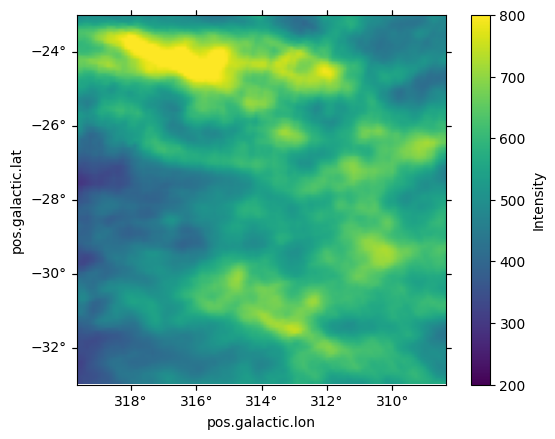

In [14]:
# New figure environment
fig, ax = plt.subplots(subplot_kw=dict(projection=w, slices=('x', 'y', 50)))

# Display image
im = ax.imshow(data_2d, cmap='viridis', origin='lower', vmin = 200, vmax = 800)

# Colorbar
plt.colorbar(im, label='Intensity')

plt.show()

In [15]:
# Inference — RMSE models for k_min and k_max
# ResNet50 regression heads trained with RMSE loss on 128×128 fractal images.
# Models: outputs/comparison/loss_benchmark/{k_min,k_max}/rmse/best_model.pt

from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torchvision.transforms.functional import resize as tf_resize
import torch.nn.functional as F

# ── Model definition (must match loss_benchmark.ipynb Cell 2) ─────────────
class ResNet50Regressor(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.backbone = models.resnet50(weights=None)
        self.backbone.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_feats, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.backbone(x).squeeze(-1)

# ── Paths ─────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_BASE = PROJECT_ROOT / 'outputs' / 'comparison' / 'loss_benchmark'
KMIN_MODEL_PATH = MODEL_BASE / 'k_min' / 'rmse' / 'best_model.pt'
KMAX_MODEL_PATH = MODEL_BASE / 'k_max' / 'rmse' / 'best_model.pt'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load models ───────────────────────────────────────────────────────────
model_kmin = ResNet50Regressor(in_channels=1).to(DEVICE)
model_kmax = ResNet50Regressor(in_channels=1).to(DEVICE)

model_kmin.load_state_dict(torch.load(KMIN_MODEL_PATH, map_location=DEVICE))
model_kmax.load_state_dict(torch.load(KMAX_MODEL_PATH, map_location=DEVICE))
model_kmin.eval()
model_kmax.eval()

print(f"Loaded k_min RMSE model  →  {KMIN_MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Loaded k_max RMSE model  →  {KMAX_MODEL_PATH.relative_to(PROJECT_ROOT)}")

# ── Preprocessing ──────────────────────────────────────────────────────────
# Training normalization: per-image min-max → [0, 1], then resize to 128×128.
# k_min range used during training: [1, 62]; k_max range: [5, 64].
KMIN_MIN, KMIN_MAX = 1.0, 62.0
KMAX_MIN, KMAX_MAX = 5.0, 64.0
TRAIN_SIZE = 128

def preprocess(img2d: np.ndarray) -> torch.Tensor:
    """Normalise a 2D image and resize to (1,1,128,128) ready for the model."""
    img = img2d.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)   # (1,1,H,W)
    if t.shape[-2:] != (TRAIN_SIZE, TRAIN_SIZE):
        t = F.interpolate(t, size=(TRAIN_SIZE, TRAIN_SIZE), mode='bilinear', align_corners=False)
    return t.to(DEVICE)

@torch.no_grad()
def predict(img2d: np.ndarray) -> dict:
    t = preprocess(img2d)
    kmin_norm = model_kmin(t).item()
    kmax_norm = model_kmax(t).item()
    return {
        'k_min': kmin_norm * (KMIN_MAX - KMIN_MIN) + KMIN_MIN,
        'k_max': kmax_norm * (KMAX_MAX - KMAX_MIN) + KMAX_MIN,
    }

# ── Run inference on all 2D images ────────────────────────────────────────
images = {
    'full integration': data_2d,
    'channel 1 (v1)':  data_ch1,
    'channel 2 (v2)':  data_ch2,
    'channel 3 (v3)':  data_ch3,
    'channel 4 (v4)':  data_ch4,
    'channel 5 (v5)':  data_ch5,
}

print(f"\n{'Image':<22}  {'k_min':>8}  {'k_max':>8}")
print("-" * 42)
results = {}
for label, img in images.items():
    pred = predict(img)
    results[label] = pred
    print(f"{label:<22}  {pred['k_min']:>8.2f}  {pred['k_max']:>8.2f}")


Loaded k_min RMSE model  →  outputs/comparison/loss_benchmark/k_min/rmse/best_model.pt
Loaded k_max RMSE model  →  outputs/comparison/loss_benchmark/k_max/rmse/best_model.pt

Image                      k_min     k_max
------------------------------------------
full integration            2.45     24.76
channel 1 (v1)              2.45     15.61
channel 2 (v2)             10.50     46.77
channel 3 (v3)              2.45     24.74
channel 4 (v4)              2.45     12.52
channel 5 (v5)              9.10     53.70


## Fourier Analysis

Characterise the spatial power spectrum of the HI emission maps:
1. **2D FFT + fftshift** — zero frequency shifted to the image centre
2. **1D kx projection** — marginal power spectrum along the horizontal wavenumber axis
3. **Radial power spectrum** — azimuthal average P(k) vs. |k|
4. **Power law fit** — spectral index α over the inertial range
5. **Inertial range extraction** — k_min (injection scale) and k_max (dissipation scale)

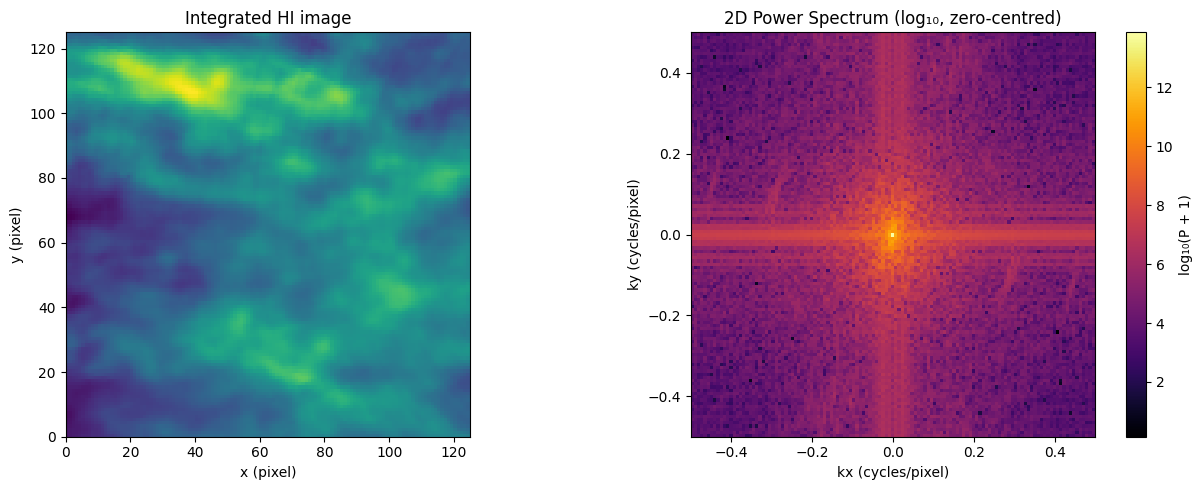

Image shape : (125, 125)
kx range    : [-0.4960, 0.4960] cycles/pixel
Power range : [3.79e-01, 7.47e+13]


In [16]:
# Cell F2 — 2D FFT + fftshift + power spectrum display
from numpy.fft import fft2, fftshift, fftfreq

# Apply to the full velocity-integrated image (defined in cell above)
img = data_2d.astype(np.float64)

F         = fft2(img)
F_shifted = fftshift(F)         # zero frequency → centre
P2D       = np.abs(F_shifted) ** 2

Ny, Nx = img.shape
kx = fftshift(fftfreq(Nx))     # horizontal freq axis (cycles/pixel)
ky = fftshift(fftfreq(Ny))     # vertical   freq axis

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pcolor(img, cmap='viridis')
axes[0].set_title('Integrated HI image')
axes[0].set_xlabel('x (pixel)'); axes[0].set_ylabel('y (pixel)')
axes[0].set_aspect('equal')

im = axes[1].pcolor(kx, ky, np.log10(P2D + 1), cmap='inferno')
axes[1].set_title('2D Power Spectrum (log₁₀, zero-centred)')
axes[1].set_xlabel('kx (cycles/pixel)'); axes[1].set_ylabel('ky (cycles/pixel)')
axes[1].set_aspect('equal')
plt.colorbar(im, ax=axes[1], label='log₁₀(P + 1)')

plt.tight_layout()
plt.show()

print(f'Image shape : {img.shape}')
print(f'kx range    : [{kx.min():.4f}, {kx.max():.4f}] cycles/pixel')
print(f'Power range : [{P2D.min():.2e}, {P2D.max():.2e}]')

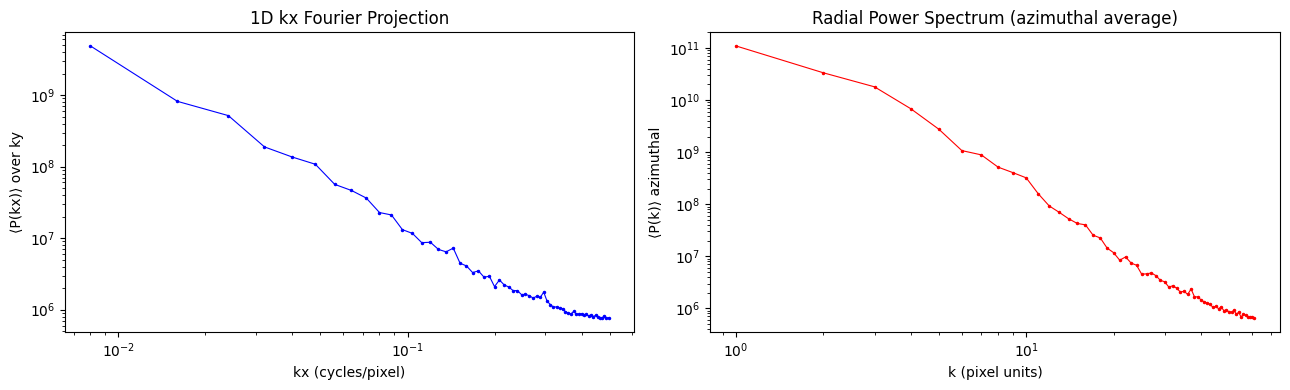

kx projection  : 62 positive frequencies
Radial spectrum: 61 k values  (1 → 61 pixels)


In [21]:
# Cell F3 — 1D kx projection and radial (azimuthal average) power spectrum

# ── kx projection: mean P2D along ky ──────────────────────────────────────
P_kx     = P2D.mean(axis=0)    # (Nx,)
mask_pos = kx > 0
kx_pos   = kx[mask_pos]
P_kx_pos = P_kx[mask_pos]

# ── Radial (azimuthal average) power spectrum ─────────────────────────────
cy, cx  = Ny // 2, Nx // 2
y_idx, x_idx = np.mgrid[:Ny, :Nx]
r_px    = np.sqrt((x_idx - cx)**2 + (y_idx - cy)**2)
r_int   = r_px.astype(int)

k_max_rad = min(cx, cy)
k_rad     = np.arange(1, k_max_rad)
P_rad     = np.array([P2D[r_int == k].mean() if (r_int == k).any() else 0.0
                      for k in k_rad])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].loglog(kx_pos, P_kx_pos, 'b.-', markersize=3, linewidth=0.8)
axes[0].set_xlabel('kx (cycles/pixel)')
axes[0].set_ylabel('⟨P(kx)⟩ over ky')
axes[0].set_title('1D kx Fourier Projection')

axes[1].loglog(k_rad, P_rad, 'r.-', markersize=3, linewidth=0.8)
axes[1].set_xlabel('k (pixel units)')
axes[1].set_ylabel('⟨P(k)⟩ azimuthal')
axes[1].set_title('Radial Power Spectrum (azimuthal average)')

plt.tight_layout()
plt.show()

print(f'kx projection  : {len(kx_pos)} positive frequencies')
print(f'Radial spectrum: {len(k_rad)} k values  (1 → {k_max_rad-1} pixels)')

Power law fit  (k = [3, 43] pixels)
  α      = -3.703
  R²     = 0.9938
  stderr = 0.0468

Reference values:
  Kolmogorov 3D  α = -3.667
  Projected 2D   α = -2.667


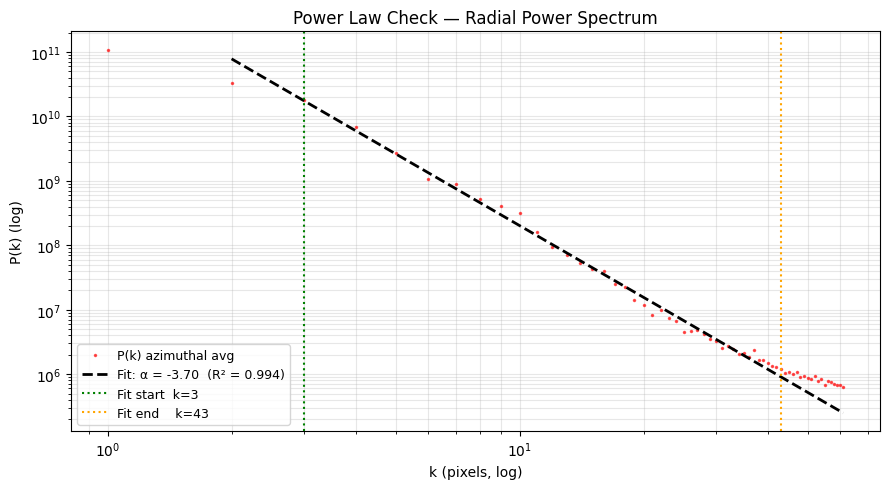

In [18]:
# Cell F4 — Power law fit: P(k) ~ k^α  in log-log space
# Kolmogorov 3D turbulence:         α ≈ −11/3 ≈ −3.67
# 2D projection of 3D turbulence:   α ≈  −8/3 ≈ −2.67

from scipy.stats import linregress

# Fit range: exclude the DC component and high-k noise
k_lo_frac, k_hi_frac = 0.05, 0.70
k_lo = max(2, int(k_lo_frac * k_max_rad))
k_hi = int(k_hi_frac * k_max_rad)

mask_fit = (k_rad >= k_lo) & (k_rad <= k_hi) & (P_rad > 0)
log_k    = np.log10(k_rad[mask_fit].astype(float))
log_P    = np.log10(P_rad[mask_fit])

slope, intercept, r_value, p_value, stderr = linregress(log_k, log_P)
alpha = slope

print(f'Power law fit  (k = [{k_lo}, {k_hi}] pixels)')
print(f'  α      = {alpha:.3f}')
print(f'  R²     = {r_value**2:.4f}')
print(f'  stderr = {stderr:.4f}')
print(f'\nReference values:')
print(f'  Kolmogorov 3D  α = {-11/3:.3f}')
print(f'  Projected 2D   α = {-8/3:.3f}')

# Plot
k_plot  = np.logspace(np.log10(k_rad[1]), np.log10(k_rad[-1]), 300)
P_model = 10**(intercept + alpha * np.log10(k_plot))

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(k_rad, P_rad, 'r.', markersize=3, alpha=0.6, label='P(k) azimuthal avg')
ax.loglog(k_plot, P_model, 'k--', linewidth=2,
          label=f'Fit: α = {alpha:.2f}  (R² = {r_value**2:.3f})')
ax.axvline(k_lo, color='green',  linestyle=':', linewidth=1.5, label=f'Fit start  k={k_lo}')
ax.axvline(k_hi, color='orange', linestyle=':', linewidth=1.5, label=f'Fit end    k={k_hi}')
ax.set_xlabel('k (pixels, log)'); ax.set_ylabel('P(k) (log)')
ax.set_title('Power Law Check — Radial Power Spectrum')
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Power law: α = -3.703  (R² = 0.9938)

FFT inertial range (threshold ±0.5 dex):
  k_min ≈ 2 pixels   (injection scale)
  k_max ≈ 61 pixels   (dissipation / noise scale)

Image                         α  kmin(FFT)  kmax(FFT)  kmin(CNN)  kmax(CNN)
--------------------------------------------------------------------------------
full integration         -3.703          2         61       2.45      24.76
channel 1 (v1)           -1.154          2         48       2.45      15.61
channel 2 (v2)           -0.832          2         48      10.50      46.77
channel 3 (v3)           -3.704          2         61       2.45      24.74
channel 4 (v4)           -2.336          2         61       2.45      12.52
channel 5 (v5)           -0.889          2         48       9.10      53.70


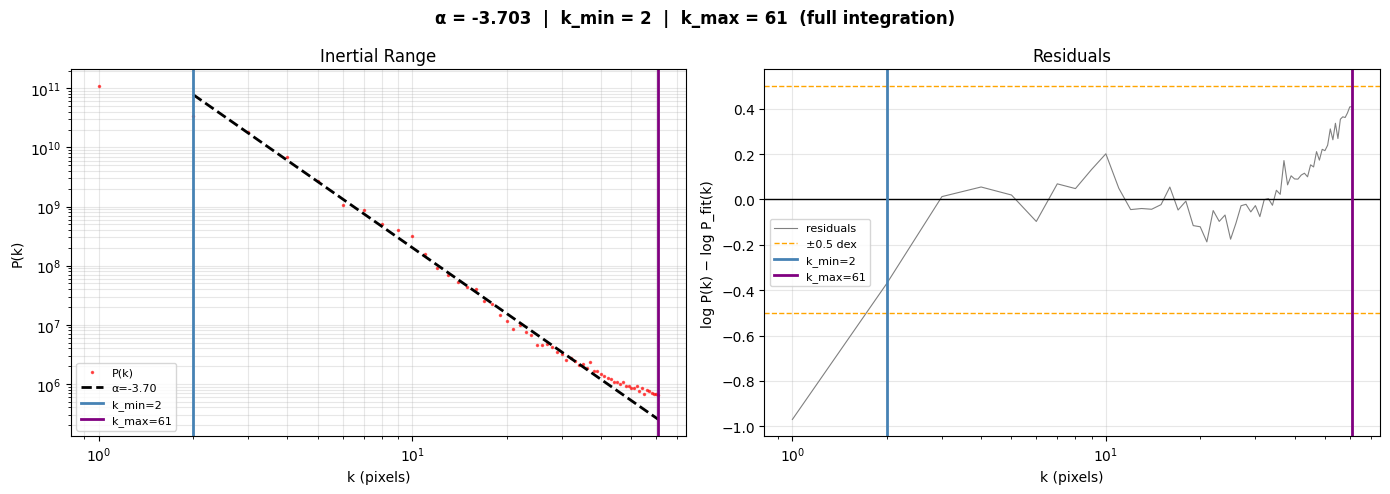

In [22]:
# Cell F5 — k_min / k_max from power-law inertial range
#            + comparison with CNN predictions from the RMSE models above
#
# Method: compute log residuals from the fitted line;
# k_min / k_max are the first / last k where |residual| < threshold.

# ── Residual-threshold method ─────────────────────────────────────────────
log_k_all    = np.log10(k_rad.astype(float))
log_P_all    = np.log10(P_rad + 1e-30)
log_P_fitted = intercept + alpha * log_k_all
residuals    = log_P_all - log_P_fitted

threshold = 0.5        # ±0.5 dex from the fitted line

in_range  = np.abs(residuals) < threshold
k_min_fft = int(k_rad[in_range][0])  if in_range.any() else k_lo
k_max_fft = int(k_rad[in_range][-1]) if in_range.any() else k_hi

print(f'Power law: α = {alpha:.3f}  (R² = {r_value**2:.4f})')
print(f'\nFFT inertial range (threshold ±{threshold} dex):')
print(f'  k_min ≈ {k_min_fft} pixels   (injection scale)')
print(f'  k_max ≈ {k_max_fft} pixels   (dissipation / noise scale)')

# ── Run for all 2D channel images ─────────────────────────────────────────
def fourier_params(img2d, k_lo_frac=0.05, k_hi_frac=0.70, thr=0.5):
    """Return spectral index alpha, k_min, k_max from the azimuthal power spectrum."""
    from scipy.stats import linregress as _lr
    F   = fftshift(fft2(img2d.astype(np.float64)))
    P   = np.abs(F) ** 2
    ny, nx = P.shape
    cy, cx = ny // 2, nx // 2
    y_i, x_i = np.mgrid[:ny, :nx]
    r_i = np.sqrt((x_i - cx)**2 + (y_i - cy)**2).astype(int)
    km  = min(cx, cy)
    kr  = np.arange(1, km)
    Pr  = np.array([P[r_i == k].mean() if (r_i == k).any() else 0.0 for k in kr])
    klo = max(2, int(k_lo_frac * km));  khi = int(k_hi_frac * km)
    mf  = (kr >= klo) & (kr <= khi) & (Pr > 0)
    if mf.sum() < 3:
        return {'alpha': np.nan, 'k_min': np.nan, 'k_max': np.nan}
    sl, ic, _, _, _ = _lr(np.log10(kr[mf].astype(float)), np.log10(Pr[mf]))
    res  = np.log10(Pr + 1e-30) - (ic + sl * np.log10(kr.astype(float)))
    inr  = np.abs(res) < thr
    return {'alpha': sl,
            'k_min': int(kr[inr][0])  if inr.any() else klo,
            'k_max': int(kr[inr][-1]) if inr.any() else khi}


chan_imgs = {
    'full integration': data_2d,
    'channel 1 (v1)':  data_ch1,
    'channel 2 (v2)':  data_ch2,
    'channel 3 (v3)':  data_ch3,
    'channel 4 (v4)':  data_ch4,
    'channel 5 (v5)':  data_ch5,
}

print(f"\n{'Image':<22}  {'α':>7}  {'kmin(FFT)':>9}  {'kmax(FFT)':>9}  "
      f"{'kmin(CNN)':>9}  {'kmax(CNN)':>9}")
print('-' * 80)
for label, img in chan_imgs.items():
    fp  = fourier_params(img)
    cnn = results.get(label, {})
    print(f"{label:<22}  {fp['alpha']:>7.3f}  {fp['k_min']:>9}  {fp['k_max']:>9}"
          f"  {cnn.get('k_min', float('nan')):>9.2f}  {cnn.get('k_max', float('nan')):>9.2f}")

# ── Summary plot for the full integrated image ─────────────────────────────
k_dense = np.logspace(np.log10(k_rad[1]), np.log10(k_rad[-1]), 300)
P_dense = 10**(intercept + alpha * np.log10(k_dense))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.loglog(k_rad, P_rad, 'r.', markersize=3, alpha=0.6, label='P(k)')
ax.loglog(k_dense, P_dense, 'k--', linewidth=2, label=f'α={alpha:.2f}')
ax.axvline(k_min_fft, color='steelblue', linewidth=2, label=f'k_min={k_min_fft}')
ax.axvline(k_max_fft, color='purple',    linewidth=2, label=f'k_max={k_max_fft}')
ax.set_xlabel('k (pixels)'); ax.set_ylabel('P(k)')
ax.set_title('Inertial Range'); ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

ax2 = axes[1]
ax2.semilogx(k_rad, residuals, color='gray', linewidth=0.8, label='residuals')
ax2.axhline(0,           color='black',  linewidth=1)
ax2.axhline( threshold,  color='orange', linestyle='--', linewidth=1)
ax2.axhline(-threshold,  color='orange', linestyle='--', linewidth=1, label=f'±{threshold} dex')
ax2.axvline(k_min_fft, color='steelblue', linewidth=2, label=f'k_min={k_min_fft}')
ax2.axvline(k_max_fft, color='purple',    linewidth=2, label=f'k_max={k_max_fft}')
ax2.set_xlabel('k (pixels)'); ax2.set_ylabel('log P(k) − log P_fit(k)')
ax2.set_title('Residuals'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle(f'α = {alpha:.3f}  |  k_min = {k_min_fft}  |  k_max = {k_max_fft}  (full integration)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()